In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [7]:
sys.path.append('C:/Users/rishe/Dissertation')

In [8]:
EXP_ID = f'exp_7_multiscale_lstm_no_attention_seasonal_focal_loss'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [9]:
df_long = pd.read_parquet(DATA_PATH)

In [10]:
df_long.shape

(4741665, 11)

In [11]:
df_long['station_id'].nunique()

293

### Data Pre-processing

In [12]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [13]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [14]:
df_long = df_long.dropna(subset=['rainfall'])

In [15]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [16]:
station_summary.head()

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847


In [17]:
station_summary['rainy_days'].sum()

1121149

### Data Splits

In [18]:
from utils.data_utils.data_helper_utils import temporal_split

In [19]:
df_train, df_val, df_test = temporal_split(df_long)

### Dataset Preparation

In [25]:
from utils.data_utils.dataset_files.multiscale_dataset import MultiScaleRainfallDataset

In [21]:
# Experiment configuration
H = 1  # Horizon
L = 30  # Window length
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Window length: {L}")
print(f"Horizon: {H}")

Device: cuda
Window length: 30
Horizon: 1


In [22]:
y_median = np.median(df_train["rainfall"])
y_iqr = np.percentile(df_train["rainfall"], 75) - np.percentile(df_train["rainfall"], 25)
print(f"Median of rainfall: {y_median}")
print(f"IQR of rainfall: {y_iqr}")

Median of rainfall: 0.0
IQR of rainfall: 1.5


In [23]:
df_train['rainfall'].describe()

count    2.771269e+06
mean     5.462160e+00
std      1.699619e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.500000e+00
max      8.810000e+02
Name: rainfall, dtype: float64

In [24]:
df_test['rainfall'].describe()

count    594017.000000
mean          5.576334
std          17.485637
min           0.000000
25%           0.000000
50%           0.000000
75%           1.400000
max         651.000000
Name: rainfall, dtype: float64

In [26]:
train_ds = MultiScaleRainfallDataset(df_train, y_median, y_iqr,min_days_per_station=L + H)
val_ds   = MultiScaleRainfallDataset(df_val,   y_median, y_iqr,min_days_per_station=L + H)
# test_ds  = MultiScaleRainfallDataset(df_test,  y_median, y_iqr,min_days_per_station=L + H)


In [27]:
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
# print(f"Test samples: {len(test_ds)}")

Train samples: 2762186
Val samples: 584970


### Import Loss Functions and Models

In [28]:
# Import custom loss function
from utils.loss import SeasonalFocalMSELoss

# Import model trainer that accepts custom criterion
from models.lstm_with_simple_self_cross_attention import MultiScaleLSTM, train_model, evaluate_on_test

# Import metrics
from utils.metric_utils.metrics import rmse, mae, bias, nrmse, seasonal_subset, stationwise_metrics

print("Imports successful!")

Imports successful!


### Training with Focal Loss

In [29]:
# Focal loss configuration
FOCAL_GAMMA = 2.0
criterion = SeasonalFocalMSELoss(gamma=FOCAL_GAMMA, reduction='mean')

print(f"Criterion: SeasonalFocalMSELoss (gamma={FOCAL_GAMMA})")
print(f"Criterion type: {type(criterion)}")

Criterion: SeasonalFocalMSELoss (gamma=2.0)
Criterion type: <class 'utils.loss.SeasonalFocalMSELoss'>


In [30]:
# Model configuration
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
HIDDEN_DIM = 128

# Setup paths
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"

print(f"Model save path: {model_save_path}")
print(f"Log save path: {log_save_path}")

Model save path: C:/Users/rishe/Dissertation/experiments/saved_models/exp_7_multiscale_lstm_no_attention_seasonal_focal_loss
Log save path: C:/Users/rishe/Dissertation/experiments/logs/exp_7_multiscale_lstm_no_attention_seasonal_focal_loss


In [34]:
model = MultiScaleLSTM(
    input_dim=7,              # rainfall + sin/cos features
    hidden_dim=128,
    num_layers=1,
    use_self_attention=False,  # optional
    use_cross_attention=False # start simple
).to(device)


In [35]:
# Train model with focal loss as criterion
from datetime import datetime

print(f"\n{'='*60}")
print(f"Starting training with FocalMSELoss")
print(f"Start time: {datetime.now()}")
print(f"{'='*60}")

trained_model = train_model(
    train_ds=train_ds,
    val_ds=val_ds,
    model=model,
    device=device,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    criterion=criterion,  # Pass FocalMSELoss as criterion
    save_dir=model_save_path,
    log_dir=log_save_path,
    experiment_name=EXP_ID
)

print(f"\nEnd time: {datetime.now()}")
print(f"Training completed successfully!")


Starting training with FocalMSELoss
Start time: 2026-02-10 18:27:42.550832


Train:   0%|          | 0/43160 [00:05<?, ?it/s]

Eval:   0%|          | 0/9141 [00:04<?, ?it/s]

2026-02-10 18:32:37 | INFO | Epoch 001 | Train Loss: 273.831441 | Val Loss: 290.364596


Train:   0%|          | 0/43160 [00:04<?, ?it/s]

...

Eval:   0%|          | 0/9141 [00:04<?, ?it/s]

2026-02-10 19:15:59 | INFO | Epoch 009 | Train Loss: 271.371815 | Val Loss: 290.184250


Train:   0%|          | 0/43160 [00:05<?, ?it/s]

Eval:   0%|          | 0/9141 [00:03<?, ?it/s]

2026-02-10 19:21:44 | INFO | Epoch 010 | Train Loss: 271.291664 | Val Loss: 289.246642

End time: 2026-02-10 19:21:44.655797
Training completed successfully!


In [36]:
test_ds  = MultiScaleRainfallDataset(df_test,  y_median, y_iqr,min_days_per_station=L + H)

In [37]:
# Evaluate on test set
print(f"\n{'='*60}")
print(f"Evaluating on test set")
print(f"{'='*60}")

test_metrics = evaluate_on_test(
    test_ds,
    trained_model,
    device
)

print("\nTest Metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


Evaluating on test set
2026-02-10 19:23:55 | INFO | RMSE_scaled: 10.5438
2026-02-10 19:23:55 | INFO | MAE_scaled: 4.6951
2026-02-10 19:23:55 | INFO | Bias_scaled: 0.3053
2026-02-10 19:23:55 | INFO | NRMSE_scaled: 2.8246

Test Metrics:
RMSE_scaled: 10.5438
MAE_scaled: 4.6951
Bias_scaled: 0.3053
NRMSE_scaled: 2.8246


### Evaluation

In [38]:
# Load best checkpoint (epoch 9)
ckpt_path = f"{model_save_path}/epoch_9.pt"
print(f"Loading checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)
trained_model.load_state_dict(checkpoint["model_state_dict"])
trained_model.to(device)
trained_model.eval()

print("Checkpoint loaded successfully!")

Loading checkpoint: C:/Users/rishe/Dissertation/experiments/saved_models/exp_7_multiscale_lstm_no_attention_seasonal_focal_loss/epoch_9.pt
Checkpoint loaded successfully!


C:\Users\rishe\AppData\Local\Temp\ipykernel_24796\3334625799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


In [39]:
from torch.utils.data import DataLoader

@torch.no_grad()
def collect_test_predictions(test_ds, model, device):
    model.to(device)
    model.eval()

    loader = DataLoader(
        test_ds,
        batch_size=128,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    rows = []

    for X3, X7, X14, X30, y, month, station_id, lat, lon in loader:
        X3 = X3.to(device)
        X7 = X7.to(device)
        X14 = X14.to(device)
        X30 = X30.to(device)

        preds = model(X3, X7, X14, X30).cpu().numpy()
        y = y.numpy()

        for i in range(len(y)):
            rows.append({
                "y": float(y[i]),
                "yhat": float(preds[i]),
                "month": int(month[i]),
                "station_id": station_id[i],
                "lat": float(lat[i]),
                "lon": float(lon[i]),
            })

    return pd.DataFrame(rows)


In [40]:
# Collect test predictions
df_eval = collect_test_predictions(
    test_ds=test_ds,
    model=trained_model,
    device=device
)

print(f"Predictions collected: {len(df_eval)} samples")
df_eval.head()

Predictions collected: 585119 samples


,y,yhat,month,station_id,lat,lon
0,0.0,4.553665,8,AKRIGANJ,NaN,NaN
1,0.0,4.976584,8,AKRIGANJ,NaN,NaN
2,0.0,4.653000,8,AKRIGANJ,NaN,NaN
3,0.0,4.171138,8,AKRIGANJ,NaN,NaN
4,3.2,4.505384,8,AKRIGANJ,NaN,NaN


In [42]:
print(df_eval[["y", "yhat"]].describe())

                   y           yhat
count  585119.000000  585119.000000
mean        3.732921       3.766452
std        11.685878       4.657504
min         0.000000      -5.003671
25%         0.000000       0.678214
50%         0.000000       1.858488
75%         1.000000       5.290390
max       434.000000      51.435898


In [43]:
df = df_eval.copy()

In [44]:
df_eval["y"] = df_eval["y"] * y_iqr + y_median
df_eval["yhat"] = df_eval["yhat"] * y_iqr + y_median


In [45]:
# Calculate error metrics
df_eval["error"] = df_eval["y"] - df_eval["yhat"]

# Create masks for analysis
rainy_mask = df_eval["y"] > 0
non_rainy_mask = df_eval["y"] == 0

monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

monsoon_mask = df_eval["month"].isin(monsoon_months)
non_monsoon_mask = df_eval["month"].isin(non_monsoon_months)

print("Error metrics and masks calculated")

Error metrics and masks calculated


### Overall Evaluation Metrics

In [46]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

print("\nOverall Evaluation Metrics (FocalMSELoss):")
print(pd.DataFrame(overall_metrics, index=["Focal Loss Model"]).round(4))


Overall Evaluation Metrics (FocalMSELoss):
                     RMSE     MAE    Bias   NRMSE
Focal Loss Model  15.8327  6.8987  0.0503  2.8276


### Seasonal Evaluation

In [47]:
df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

print("\nSeasonal Performance:")
print(seasonal_metrics.round(4))


Seasonal Performance:
                RMSE      MAE    Bias
Monsoon      23.0319  13.0307 -0.3900
Non-Monsoon   8.7464   3.0815  0.3244


### Per-Station Performance

In [48]:
df_station_metrics = stationwise_metrics(df_eval)

print("\nStation-wise metrics summary:")
print(df_station_metrics.describe().round(4))


Station-wise metrics summary:
           RMSE       MAE      Bias      Count
count  283.0000  283.0000  283.0000   283.0000
mean    13.8399    6.6349    0.1768  2067.5583
std      6.6165    2.9021    1.4138  1583.1979
min      0.7428    0.7428   -6.0578     1.0000
25%     10.1883    5.0772   -0.1181   798.5000
50%     12.3723    5.8571    0.5172  1746.0000
75%     16.3532    8.0937    0.8509  2915.0000
max     40.6867   20.7733    5.7703  6532.0000


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


### Month-wise RMSE

C:\Users\rishe\AppData\Local\Temp\ipykernel_24796\1191928291.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


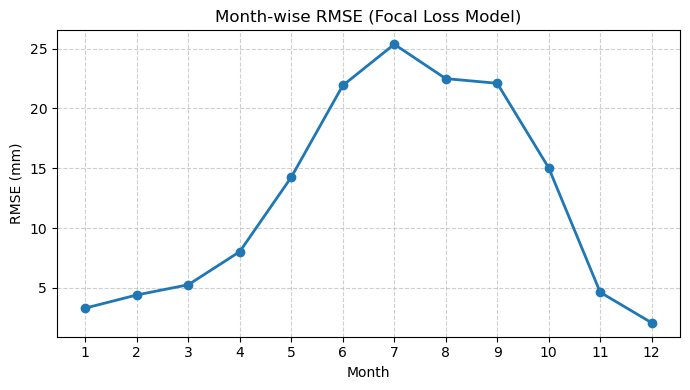

In [49]:
# Compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE (Focal Loss Model)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Error Distribution Analysis

In [50]:
# Error statistics
print("Error Statistics:")
print((df_eval['error']).describe(percentiles=[0.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, .95, .96, .97, .98, .99]).round(4))

Error Statistics:
count    585119.0000
mean         -0.0503
std          15.8326
min         -66.0644
10%          -9.3231
20%          -6.1355
25%          -4.8974
30%          -3.6860
40%          -2.1054
50%          -1.3585
60%          -0.9944
70%          -0.8004
75%          -0.7072
80%          -0.5860
90%           7.1727
95%          21.6894
96%          27.0760
97%          34.3661
98%          45.6610
99%          68.0287
max         616.5610
Name: error, dtype: float64


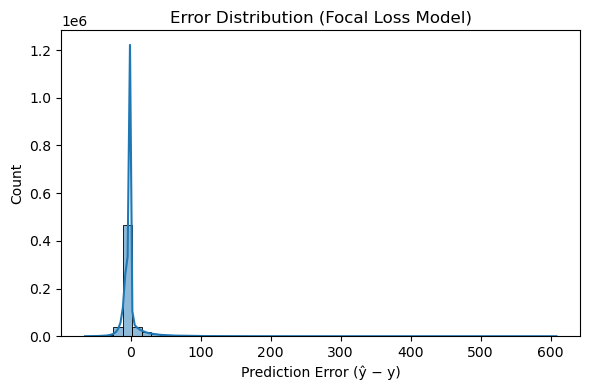

In [37]:
# Error histogram
plt.figure(figsize=(6, 4))
sns.histplot(df_eval['error'], bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution (Focal Loss Model)")
plt.tight_layout()
plt.show()

### Rainy vs Non-Rainy Analysis

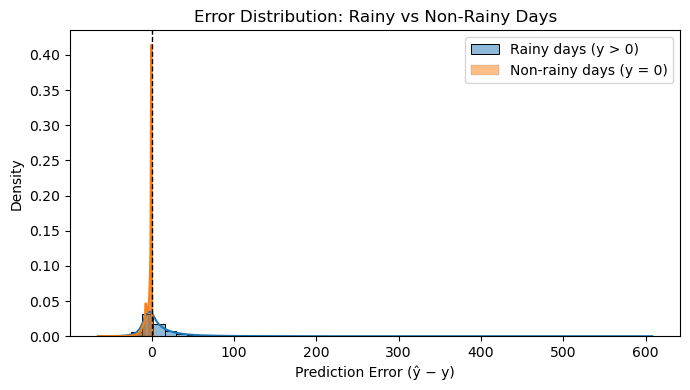

In [38]:
# Error histogram by rainfall regime
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()

### Monsoon vs Non-Monsoon Analysis

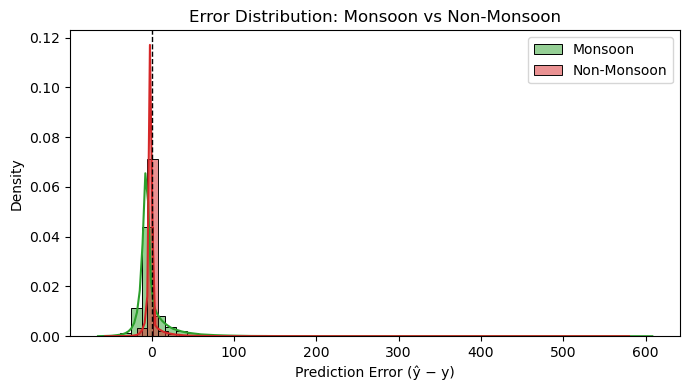

In [39]:
# Error histogram by season
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()

### Conditional RMSE Analysis

In [51]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

conditional_metrics = pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])

print("\nConditional RMSE by Rainfall Regime:")
print(conditional_metrics.round(4))


Conditional RMSE by Rainfall Regime:
          Regime     RMSE      MAE     Bias   Count
0      Non-rainy   5.5173   3.4333   3.4297  418736
1     Light rain   9.4214   6.7094   5.6163   83453
2  Moderate rain  17.3378  13.9363 -11.4988   66988
3     Heavy rain  81.6894  69.3419 -69.3220   15942


### Baseline Comparison

In [52]:
# Baseline models
yhat_zero = np.zeros_like(df_eval.y)
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Focal Loss Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

print("\nBaseline Comparison:")
print(baseline_table.round(4))


Baseline Comparison:
                     RMSE     MAE
Focal Loss Model  15.8327  6.8987
Zero Predictor    18.4014  5.5994
Mean Predictor    17.5288  8.6405


### Scatter Plot: True vs Predicted

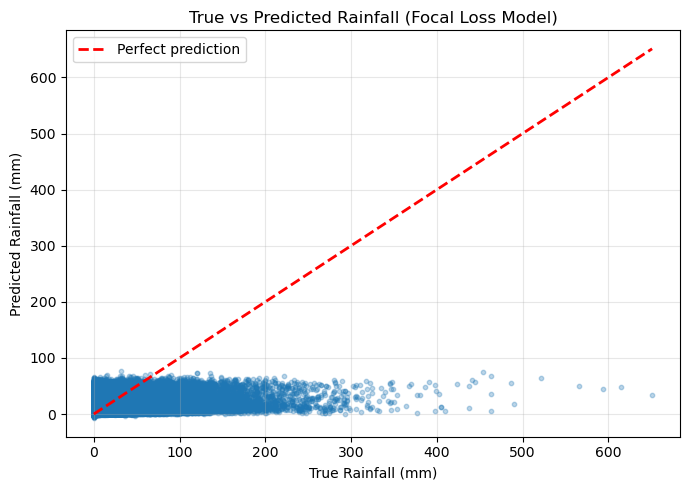

In [53]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_eval["y"],
    df_eval["yhat"],
    alpha=0.3,
    s=10
)

# Perfect prediction line
max_val = max(df_eval["y"].max(), df_eval["yhat"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted Rainfall (Focal Loss Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

In [43]:
summary_data = [
    {"Metric": "RMSE", "Value": overall_metrics["RMSE"]},
    {"Metric": "MAE", "Value": overall_metrics["MAE"]},
    {"Metric": "Bias", "Value": overall_metrics["Bias"]},
    {"Metric": "NRMSE", "Value": overall_metrics["NRMSE"]},
]

print(f"\n{'='*60}")
print(f"EXPERIMENT SUMMARY: FocalMSELoss (γ={FOCAL_GAMMA})")
print(f"{'='*60}")
print(f"Window Length: {L} days")
print(f"Horizon: {H} day")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Hidden Dimension: {HIDDEN_DIM}")
print(f"\nResults:")
print(pd.DataFrame(summary_data).to_string(index=False))
print(f"{'='*60}")


EXPERIMENT SUMMARY: FocalMSELoss (γ=2.0)
Window Length: 30 days
Horizon: 1 day
Batch Size: 64
Epochs: 10
Learning Rate: 0.001
Hidden Dimension: 128

Results:
Metric     Value
  RMSE 15.822738
   MAE  6.899314
  Bias  0.244747
 NRMSE  2.826602
